In [1]:
# [ai-generated]
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#   kernelspec:
#     display_name: Python 3
#     language: python
#     name: python3
# ---

# Span-max probe training — a stage-by-stage walkthrough

**What this is.** A faithful, visual trace of the *exact* training logic the
repo uses for the primary probe (`train_probe_spanmax.py`, the span-max loss
of Obeso, Arditi et al. 2025, arXiv:2509.03531 §3). Every stage **imports the
real source functions** — nothing here is a re-implementation, so what you see
is what training actually computes.

We trace, in order:
1. **Tokens — split & label.** code → tokens (offset map) → char-spans →
   token-spans → per-token 0/1 labels. Verified against the labels stored on
   disk by the extractor.
2. **The two-level split.** outer group-clean heldout (SVEN `pair_group_key`)
   → inner 90/10 stratified split used for epoch selection.
3. **Probe logits.** the linear probe forward pass `w·h + b` → per-token logit
   → `sigmoid` → per-token vulnerability probability.
4. **Loss anatomy.** per-token weighted BCE (`alpha`-up-weighting) + the
   span max-pool term, the `omega` 0→1 anneal, optional soft labels — each
   piece plotted, then checked against the real `span_max_loss`.
5. **Train one layer.** the real `train_one_layer` loop end-to-end; loss /
   token-AUC / example-AUC / omega curves; before-vs-after token probabilities.
6. **Example-level scoring.** the `max`-over-tokens pool and the ROC curves
   (token-level and example-level) that pick the winning layer.

**Data.** A small sample shipped under `notebooks/walkthrough/data/`:
Gemma-3-1B hidden states at **layer 13** for **150 examples** (38,750 token
positions, hidden dim 1152), plus the dataset rows, token offsets, and the
SVEN group-split metadata. Layer 13 is a stand-in for the production layer
sweep `[8, 17, 26, 34]`; the logic is identical per layer.

> **"Logits outputted by the model" — which model?** Two things produce
> numbers here. (a) *Gemma-3-1B* produces the **hidden states** `h` — already
> extracted to the `.npz`, we never re-run the LM. (b) the **linear probe**
> consumes `h` and produces the **per-token scalar logit** that the loss acts
> on. Stage 3 onward, "logits" means the probe's, since that is what training
> optimises. The LM's vocabulary logits play no role in probe training.

## Stage 0 — Setup & load the sample

Resolve the repo root, put it on `sys.path`, and import the **actual** training
and labeling functions. If any import here changed, this notebook would change
with it — that is the point.

In [2]:
import json
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

# --- locate repo root (dir containing pyproject.toml), robust to cwd ---
def _find_root(start: Path) -> Path:
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "pyproject.toml").exists():
            return cand
    raise RuntimeError("could not find repo root (pyproject.toml)")

ROOT = _find_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
DATA = ROOT / "notebooks" / "walkthrough" / "data"

# --- the REAL functions under test (imported, never re-implemented) ---
from src.eval.token_data import (
    parse_spans,
    char_spans_to_token_spans,
    token_labels_array,
    POSITIVE_KEYS,
    NEGATIVE_KEYS,
)
from src.training.train_probe_spanmax import (
    LinearProbe,
    soft_labels_triangular,
    span_max_loss,
    train_one_layer,
    _group_by_example,
    _example_label,
)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "font.size": 10, "axes.titlesize": 11})
POS_C, NEG_C, NEU_C = "#c0392b", "#2e86c1", "#bdc3c7"  # vuln / mitigated / neutral

print("repo root :", ROOT)
print("data dir  :", DATA)
print("torch     :", torch.__version__)

repo root : /Users/mmtf/p/probes-nlas-cyber
data dir  : /Users/mmtf/p/probes-nlas-cyber/notebooks/walkthrough/data
torch     : 2.12.0


Load the four artifacts. `example_ids[i]` is the dataset row index (line
number in `dataset.jsonl`) that token position `i` came from, exactly as the
extractor wrote it (`src/data/extract_token_activations.py`).

In [3]:
acts = np.load(DATA / "acts_gemma3-1b_layer13_sample.npz")
X_all   = acts["X"].astype(np.float32)        # (N_tok, dim) — stored fp16, cast to fp32 as the extractor does
y_all   = acts["y"].astype(np.int64)          # (N_tok,) per-token 0/1 label
eid_all = acts["example_ids"].astype(np.int64)  # (N_tok,) row index per token
LAYER   = int(acts["layer"])

offsets_npz = np.load(DATA / "gemma3-1b_offsets.npz")   # offsets_row_{eid:04d} -> (T,2)
spans_disk  = json.loads((DATA / "gemma3-1b_spans.json").read_text())  # [eid, tok_start, tok_end]
split_meta  = json.loads((DATA / "sven_split_meta.json").read_text())

# dataset rows, indexed by line number == example_id
rows = [json.loads(l) for l in (DATA / "dataset.jsonl").read_text().splitlines() if l.strip()]

sample_eids = np.unique(eid_all)
hidden_dim = X_all.shape[1]
print(f"layer {LAYER}: X={X_all.shape}  tokens_pos={int(y_all.sum())}/{len(y_all)}  "
      f"examples={sample_eids.size}  hidden_dim={hidden_dim}")
print(f"dataset.jsonl rows={len(rows)}  offsets rows={len(offsets_npz.files)}  "
      f"disk spans={len(spans_disk)}")
print(f"split seed={split_meta['seed']}  frac_heldout={split_meta['frac_heldout']}  "
      f"n_groups={split_meta['n_groups']}  heldout_groups={len(split_meta['heldout_groups'])}")

layer 13: X=(38750, 1152)  tokens_pos=740/38750  examples=150  hidden_dim=1152
dataset.jsonl rows=1560  offsets rows=1560  disk spans=869
split seed=42  frac_heldout=0.2  n_groups=767  heldout_groups=153


## Stage 1 — Tokens: how they are split and labeled

The extractor (`extract_token_activations.py`) does, per row:

1. `tokenizer(code, return_offsets_mapping=True, truncation=True, max_length=1024)`
   → `input_ids` and an **offset map** `(start_char, end_char)` per token.
2. `parse_spans(row)` reads the row's `token_labels` **character** ranges:
   positives = `evidence ∪ vulnerable_line ∪ sink ∪ source`, negative =
   `sanitizer` (`src/eval/token_data.py`).
3. `char_spans_to_token_spans(...)` maps each char-range to the **inclusive**
   token index range of every overlapping token.
4. `token_labels_array(n_tok, token_spans)` paints the per-token label:
   `1` inside any positive token-span, else `0`.

We reproduce this for one example **from the raw char-spans + offsets** and
confirm it equals the `y` stored on disk — proving the on-disk labels are
exactly this function's output.

In [4]:
# Pick a clear positive demo example: positive, with a labeled span, short
# enough to plot token-by-token.
def _ntok(eid: int) -> int:
    return int((eid_all == eid).sum())

pos_eids = [int(e) for e in sample_eids if y_all[eid_all == e].sum() > 0]
demo_eid = min(
    (e for e in pos_eids if 40 <= _ntok(e) <= 170),
    key=_ntok,
    default=pos_eids[0],
)
row = rows[demo_eid]
offs = [tuple(int(v) for v in o) for o in offsets_npz[f"offsets_row_{demo_eid:04d}"]]
n_tok = len(offs)

print(f"demo example_id={demo_eid}  lang={row.get('lang')}  cwe={row.get('cwe')}  "
      f"source={row.get('source')}  tokens={n_tok}")
print(f"file::func = {row.get('_file_name')}::{row.get('_func_name')}")

# (1)-(4) rebuilt from raw inputs via the REAL functions
char_spans = parse_spans(row)
tok_spans  = char_spans_to_token_spans(char_spans, offs)
labels_rebuilt, in_span_mask = token_labels_array(n_tok, tok_spans)

# the labels the extractor already wrote for this eid (in token order)
labels_disk = y_all[eid_all == demo_eid]

match = (len(labels_disk) == n_tok) and bool((labels_rebuilt == labels_disk).all())
print(f"\nchar-spans on this row: "
      f"{[(s.source_key, s.start_char, s.end_char, 'pos' if s.label else 'neg') for s in char_spans]}")
print(f"token-spans (start,end,label): {tok_spans}")
print(f"\nrebuilt labels == on-disk labels ?  {match}   "
      f"(positives: rebuilt={int(labels_rebuilt.sum())}, disk={int(labels_disk.sum())})")
assert match, "label reconstruction diverged from the stored extractor output"

demo example_id=38  lang=python  cwe=CWE-078  source=SVEN-before  tokens=40
file::func = cinder/volume/drivers/storwize_svc.py::_call_prepare_fc_map

char-spans on this row: [('evidence', 76, 114, 'pos')]
token-spans (start,end,label): [(29, 39, 1)]

rebuilt labels == on-disk labels ?  True   (positives: rebuilt=11, disk=11)


**The labeled token strip.** Each cell is one token, colored by its label.
Red = inside a positive (vulnerable) span; blue = inside a `sanitizer`
(mitigated) span; grey = out-of-span. This is the `y` the loss trains against.

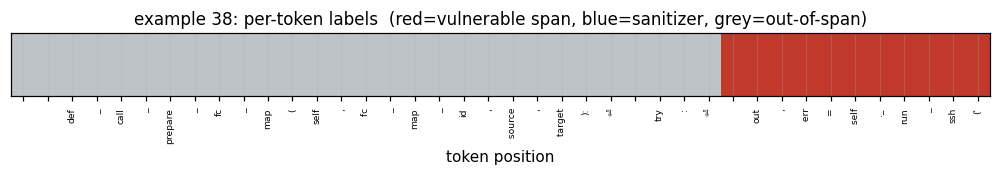

In [5]:
# negative (sanitizer) token positions, for display only
neg_mask = np.zeros(n_tok, dtype=bool)
for (s, e, lbl) in tok_spans:
    if lbl == 0:
        neg_mask[s:min(e, n_tok - 1) + 1] = True

# decode each token's text from char offsets for readable tick labels
code = row["code"]
tok_text = [code[a:b].replace("\n", "⏎") for (a, b) in offs]

strip = np.zeros((1, n_tok))
strip[0, labels_rebuilt == 1] = 1.0    # positive
strip[0, neg_mask] = -1.0              # negative

fig, ax = plt.subplots(figsize=(min(16, 0.18 * n_tok + 2), 1.7))
cmap = mcolors.ListedColormap([NEG_C, NEU_C, POS_C])
ax.imshow(strip, aspect="auto", cmap=cmap, norm=mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5], cmap.N))
ax.set_yticks([])
# annotate a sparse subset of token texts so it stays legible
step = max(1, n_tok // 48)
ticks = list(range(0, n_tok, step))
ax.set_xticks(ticks)
ax.set_xticklabels([tok_text[i] for i in ticks], rotation=90, fontsize=6)
ax.set_title(f"example {demo_eid}: per-token labels  "
             f"(red=vulnerable span, blue=sanitizer, grey=out-of-span)")
ax.set_xlabel("token position")
plt.tight_layout()
plt.show()

## Stage 2 — The two-level split

Two independent splits stack:

**(A) Outer, group-clean heldout** (`retrain_spanmax_sven_split.py`). Each row
gets a `pair_group_key` — the repo / file::func it came from — so a
SVEN before/after *pair* can never straddle train and test. 20% of *groups*
(seed 42, `sven_split_meta.json`) are held out; the probe trains on the other
80%. This is leakage control: the probe cannot memorize a function and score
its sibling.

**(B) Inner, stratified 90/10** (inside `train_one_layer`). Of the training
examples, `train_test_split(test_size=0.1, random_state=7, stratify=...)`
carves a small validation slice used only to pick the best epoch. Stratified
by example-level label so the rare positives are represented on both sides.

In [6]:
import hashlib

# pair_group_key — identical to retrain_spanmax_sven_split.pair_group_key
def pair_group_key(r: dict) -> str:
    repo = r.get("_origin_repo")
    if repo:
        return f"repo::{repo}"
    fn = r.get("_file_name") or ""
    func = r.get("_func_name") or ""
    if fn or func:
        return f"func::{fn}::{func}"
    return f"row::{hashlib.sha1((r.get('code') or '').encode('utf-8')).hexdigest()[:12]}"

heldout_groups = set(split_meta["heldout_groups"])
eid_group = {int(e): pair_group_key(rows[int(e)]) for e in sample_eids}
train_eids   = np.array([e for e in sample_eids if eid_group[int(e)] not in heldout_groups])
heldout_eids = np.array([e for e in sample_eids if eid_group[int(e)] in heldout_groups])
print(f"(A) outer group split on the sample:  train={train_eids.size}  "
      f"heldout={heldout_eids.size}  (of {sample_eids.size} examples)")

# (B) replicate the inner split exactly as train_one_layer does it
from sklearn.model_selection import train_test_split
groups = _group_by_example(X_all, y_all, eid_all)            # {eid: (X, y)}
all_eids_sorted = sorted(groups.keys())
ex_labels = np.array([_example_label(groups[e][1]) for e in all_eids_sorted])
try:
    eids_tr, eids_val = train_test_split(all_eids_sorted, test_size=0.1,
                                         random_state=7, stratify=ex_labels)
except ValueError:
    eids_tr, eids_val = train_test_split(all_eids_sorted, test_size=0.1, random_state=7)
print(f"(B) inner 90/10 (seed 7, stratified): fit={len(eids_tr)}  val={len(eids_val)}  "
      f"val positives={sum(_example_label(groups[e][1]) for e in eids_val)}")

(A) outer group split on the sample:  train=121  heldout=29  (of 150 examples)
(B) inner 90/10 (seed 7, stratified): fit=135  val=15  val positives=8


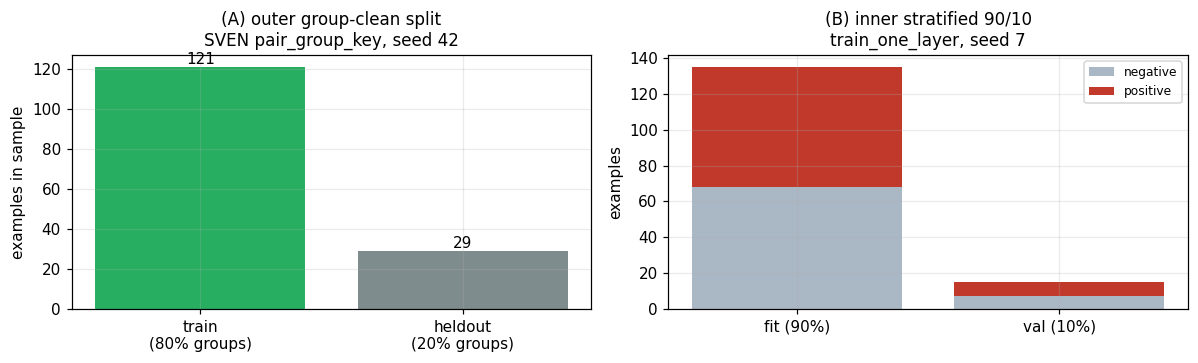

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

# (A) group split
ax = axes[0]
ax.bar(["train\n(80% groups)", "heldout\n(20% groups)"],
       [train_eids.size, heldout_eids.size], color=["#27ae60", "#7f8c8d"])
ax.set_title("(A) outer group-clean split\nSVEN pair_group_key, seed 42")
ax.set_ylabel("examples in sample")
for i, v in enumerate([train_eids.size, heldout_eids.size]):
    ax.text(i, v, str(v), ha="center", va="bottom")

# (B) inner split, split by class
ax = axes[1]
tr_pos = sum(_example_label(groups[e][1]) for e in eids_tr)
tr_neg = len(eids_tr) - tr_pos
val_pos = sum(_example_label(groups[e][1]) for e in eids_val)
val_neg = len(eids_val) - val_pos
ax.bar(["fit (90%)", "val (10%)"], [tr_neg, val_neg], label="negative", color="#aab7c4")
ax.bar(["fit (90%)", "val (10%)"], [tr_pos, val_pos], bottom=[tr_neg, val_neg],
       label="positive", color=POS_C)
ax.set_title("(B) inner stratified 90/10\ntrain_one_layer, seed 7")
ax.set_ylabel("examples")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Stage 3 — Probe logits (the forward pass)

The probe is a single linear map: for each token's hidden state `h ∈ R^1152`,
the **logit** is `z = w·h + b` (`LinearProbe`, one output unit). The per-token
**probability** is `p = sigmoid(z)`. At initialization `w, b` are random, so
`p ≈ 0.5` everywhere — the plot below is the *untrained* probe. Stage 5 shows
the same example after training.

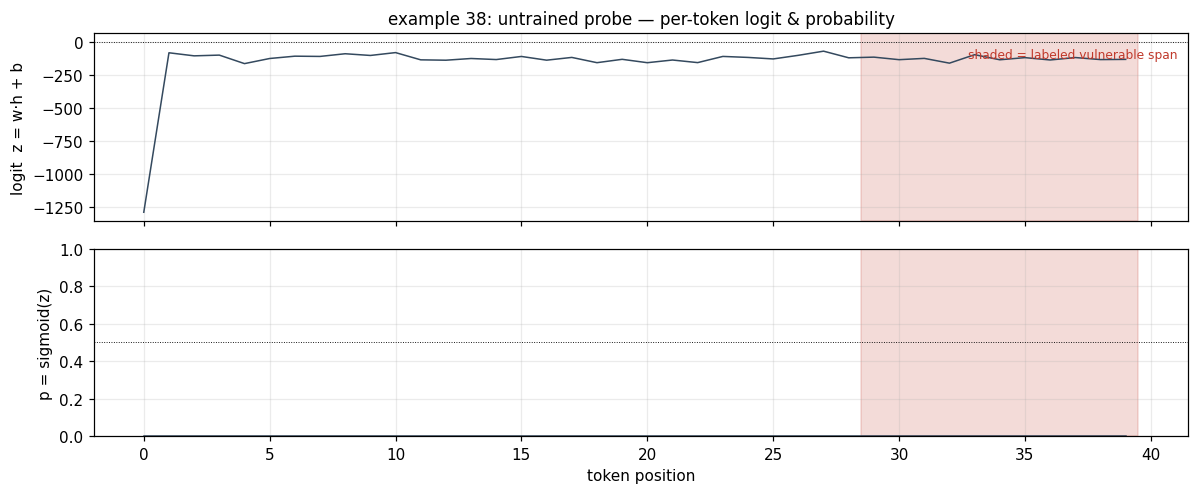

In [8]:
torch.manual_seed(0)
probe0 = LinearProbe(hidden_dim)   # random init

Xi = torch.from_numpy(X_all[eid_all == demo_eid])          # (n_tok, dim)
with torch.no_grad():
    logits0 = probe0(Xi).numpy()
    probs0  = torch.sigmoid(torch.from_numpy(logits0)).numpy()

pos_idx = np.where(labels_rebuilt == 1)[0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 4.6), sharex=True)
ax1.plot(logits0, color="#34495e", lw=1)
ax1.axhline(0, color="k", lw=0.6, ls=":")
ax1.set_ylabel("logit  z = w·h + b")
ax1.set_title(f"example {demo_eid}: untrained probe — per-token logit & probability")
ax2.plot(probs0, color="#34495e", lw=1)
ax2.axhline(0.5, color="k", lw=0.6, ls=":")
ax2.set_ylabel("p = sigmoid(z)")
ax2.set_xlabel("token position")
ax2.set_ylim(0, 1)
# shade the vulnerable span(s)
for ax in (ax1, ax2):
    for (s, e, lbl) in tok_spans:
        if lbl == 1:
            ax.axvspan(s - 0.5, min(e, n_tok - 1) + 0.5, color=POS_C, alpha=0.18)
ax1.text(0.99, 0.92, "shaded = labeled vulnerable span", transform=ax1.transAxes,
         ha="right", va="top", fontsize=8, color=POS_C)
plt.tight_layout()
plt.show()

## Stage 4 — How the loss is calculated

The span-max loss (`span_max_loss`, paper §3) is, **per example**:

$$ \ell = (1-\omega)\underbrace{\sum_{i} w_i\,\mathrm{BCE}(y_i, z_i)}_{\text{token term}}
         \;+\; \omega\underbrace{\,\mathrm{BCE}\!\big(1,\ \max_{i\in\text{span}} z_i\big)}_{\text{span term (positives only)}} $$

- **token term** — weighted binary cross-entropy at every token. Tokens inside
  a span get weight `alpha = 10`, the rest weight `1`. This is the dense signal.
- **span term** — for positive examples only: pool the **max** logit over the
  annotated span tokens and push *that one peak* toward 1. This is what makes
  it a *span*-max probe: it only needs one strong firing inside the vuln region.
- **`omega`** anneals **0 → 1** linearly over all training steps: start as pure
  dense per-token BCE, end emphasizing the max-pool objective.

The batch loss is `Σ(per-example ℓ) / Σ(tokens)` — averaged per token so scale
is batch-size invariant (`train_one_layer`).

Below we recompute each piece by hand for the demo example and **assert it
matches `span_max_loss`** at several `omega` values.

In [9]:
zi = torch.from_numpy(logits0)                  # this example's logits (untrained)
yt = torch.from_numpy(labels_rebuilt.astype(np.int64))
y_soft = torch.from_numpy(labels_rebuilt.astype(np.float32))   # label_window=0 → soft==hard
is_pos = bool(_example_label((X_all[eid_all == demo_eid], labels_rebuilt))) if False else bool(labels_rebuilt.any())
alpha = 10.0

# --- manual decomposition ---
bce_per_tok = nn.functional.binary_cross_entropy_with_logits(zi, y_soft, reduction="none")
w_i = torch.where(yt > 0, torch.full_like(bce_per_tok, alpha), torch.ones_like(bce_per_tok))
token_term = (w_i * bce_per_tok).sum()

span_logits = zi[yt > 0]
max_logit = span_logits.max()
span_term = nn.functional.binary_cross_entropy_with_logits(
    max_logit, torch.tensor(1.0), reduction="sum")

print(f"example {demo_eid}: tokens={n_tok}  span tokens={int((yt>0).sum())}  "
      f"max logit in span={max_logit.item():.3f}")
print(f"token_term={token_term.item():.3f}   span_term={span_term.item():.3f}\n")

for omega in (0.0, 0.25, 0.5, 0.75, 1.0):
    manual = (1.0 - omega) * token_term + omega * span_term
    real = span_max_loss(zi, yt, is_pos, omega=omega, alpha=alpha, y_soft=y_soft)
    ok = torch.allclose(manual, real, atol=1e-5)
    print(f"omega={omega:.2f}  manual={manual.item():9.3f}  span_max_loss={real.item():9.3f}  match={ok}")
    assert ok

example 38: tokens=40  span tokens=11  max logit in span=-98.119
token_term=14226.548   span_term=98.119

omega=0.00  manual=14226.548  span_max_loss=14226.548  match=True
omega=0.25  manual=10694.440  span_max_loss=10694.440  match=True
omega=0.50  manual= 7162.333  span_max_loss= 7162.333  match=True
omega=0.75  manual= 3630.226  span_max_loss= 3630.226  match=True
omega=1.00  manual=   98.119  span_max_loss=   98.119  match=True


**Four views of the loss machinery.**

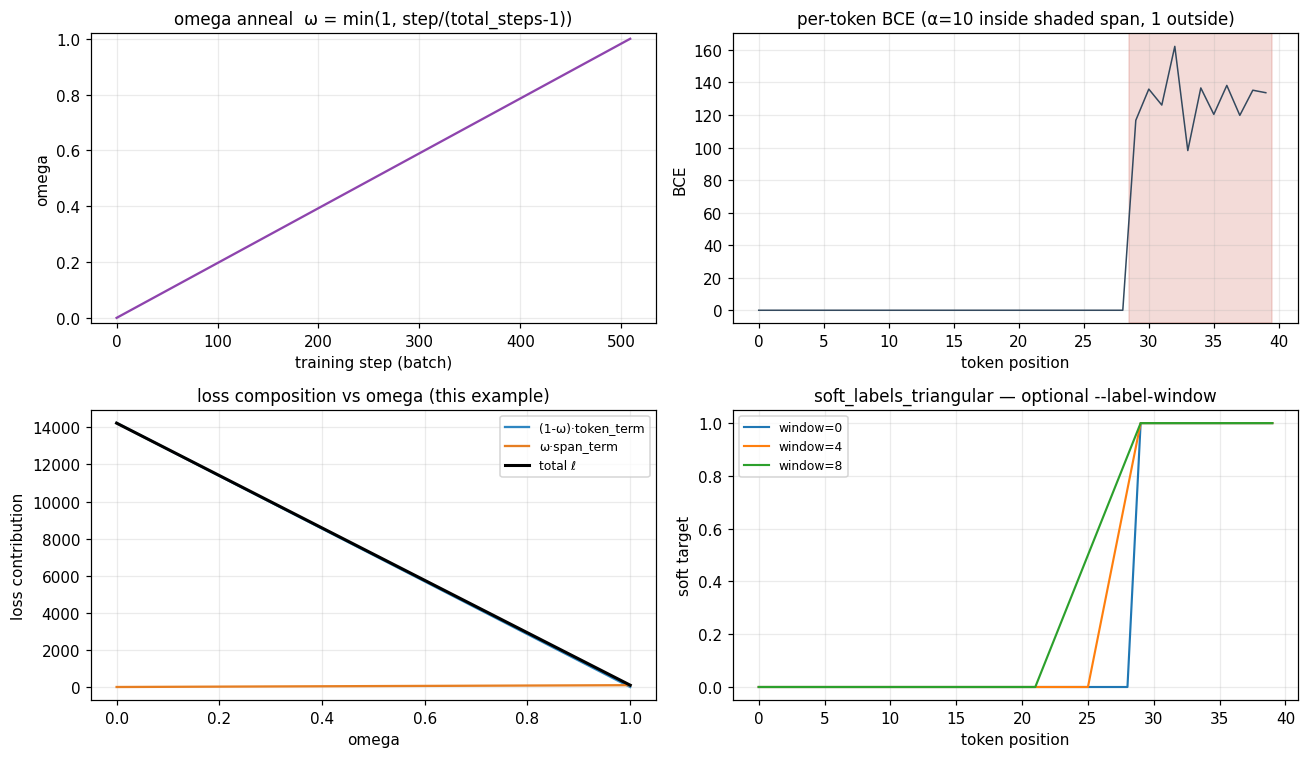

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# (1) omega anneal across the whole run (matches train_one_layer schedule)
ax = axes[0, 0]
demo_epochs, demo_bs = 30, 8
n_fit = len(eids_tr)
total_steps = max(1, demo_epochs * ((n_fit + demo_bs - 1) // demo_bs))
steps = np.arange(total_steps)
omega_curve = np.minimum(1.0, steps / max(1, total_steps - 1))
ax.plot(steps, omega_curve, color="#8e44ad")
ax.set_title("omega anneal  ω = min(1, step/(total_steps-1))")
ax.set_xlabel("training step (batch)"); ax.set_ylabel("omega")
ax.set_ylim(-0.02, 1.02)

# (2) per-token BCE and the alpha weight overlaid
ax = axes[0, 1]
ax.plot(bce_per_tok.numpy(), color="#34495e", lw=1, label="BCE per token")
for (s, e, lbl) in tok_spans:
    if lbl == 1:
        ax.axvspan(s - 0.5, min(e, n_tok - 1) + 0.5, color=POS_C, alpha=0.18)
ax.set_title(f"per-token BCE (α={alpha:.0f} inside shaded span, 1 outside)")
ax.set_xlabel("token position"); ax.set_ylabel("BCE")

# (3) token_term vs span_term as omega sweeps → the blended loss
ax = axes[1, 0]
om = np.linspace(0, 1, 101)
ax.plot(om, (1 - om) * token_term.item(), label="(1-ω)·token_term", color="#2e86c1")
ax.plot(om, om * span_term.item(), label="ω·span_term", color="#e67e22")
ax.plot(om, (1 - om) * token_term.item() + om * span_term.item(),
        label="total ℓ", color="k", lw=2)
ax.set_title("loss composition vs omega (this example)")
ax.set_xlabel("omega"); ax.set_ylabel("loss contribution"); ax.legend(fontsize=8)

# (4) soft-label triangular tail (#26): optional label smoothing
ax = axes[1, 1]
for win in (0, 4, 8):
    soft = soft_labels_triangular(labels_rebuilt.astype(np.int8), win)
    ax.plot(soft, lw=1.4, label=f"window={win}")
ax.set_title("soft_labels_triangular — optional --label-window")
ax.set_xlabel("token position"); ax.set_ylabel("soft target"); ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Stage 5 — Train one layer (the real loop, end to end)

Now we call the actual `train_one_layer` on the layer-13 sample — same
AdamW, same omega anneal, same per-token-averaged loss, same inner 90/10 split,
same "pick the epoch with the best example-AUC" selection. We just capture its
returned `history` and plot it.

best example-AUC=0.625  best token-AUC=0.777  n_train=135  n_val=15


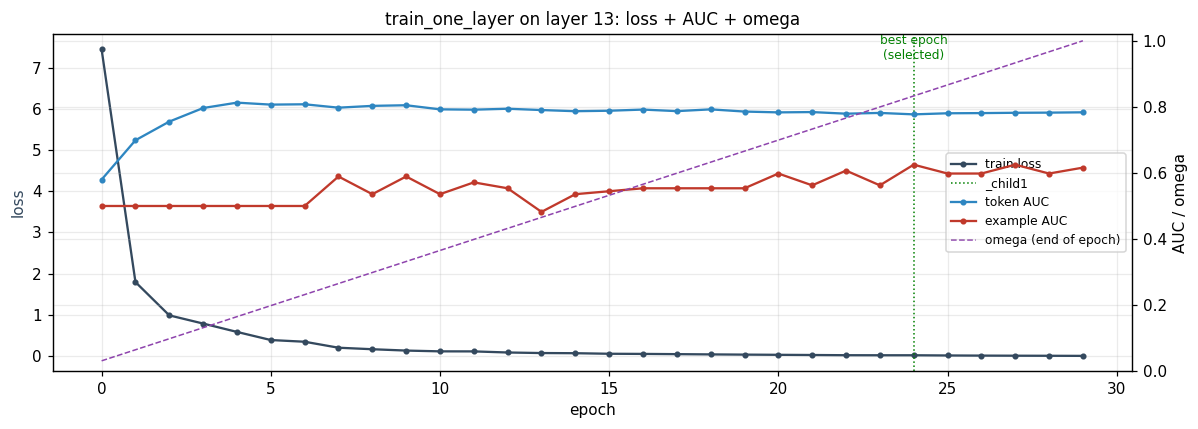

In [11]:
result = train_one_layer(
    X_all, y_all, eid_all,
    epochs=30, lr=1e-3, batch_examples=8,
    seed=7, device="cpu", verbose=False, label_window=0,
)
hist = result["history"]
ep      = [h["epoch"] for h in hist]
loss_c  = [h["loss"] for h in hist]
tok_auc = [h["tok_auc"] for h in hist]
ex_auc  = [h["ex_auc"] for h in hist]
om_end  = [h["omega_end"] for h in hist]

print(f"best example-AUC={result['ex_auc']:.3f}  best token-AUC={result['tok_auc']:.3f}  "
      f"n_train={result['n_train_examples']}  n_val={result['n_eval_examples']}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ep, loss_c, color="#34495e", marker=".", label="train loss")
ax.set_xlabel("epoch"); ax.set_ylabel("loss", color="#34495e")
ax2 = ax.twinx()
ax2.plot(ep, tok_auc, color="#2e86c1", marker=".", label="token AUC")
ax2.plot(ep, ex_auc, color=POS_C, marker=".", label="example AUC")
ax2.plot(ep, om_end, color="#8e44ad", ls="--", lw=1, label="omega (end of epoch)")
ax2.set_ylabel("AUC / omega"); ax2.set_ylim(0, 1.02)
best_ep = int(np.nanargmax([e if not np.isnan(e) else -1 for e in ex_auc]))
ax.axvline(best_ep, color="green", ls=":", lw=1)
ax.text(best_ep, ax.get_ylim()[1], "best epoch\n(selected)", color="green",
        fontsize=8, va="top", ha="center")
lines = ax.get_lines() + ax2.get_lines()
ax.legend(lines, [l.get_label() for l in lines], loc="center right", fontsize=8)
ax.set_title(f"train_one_layer on layer {LAYER}: loss + AUC + omega")
plt.tight_layout()
plt.show()

**Before vs after** on the demo example. Reconstruct the trained probe from
the returned `(w, b)` and recompute its per-token probabilities. The trained
probe should lift probability inside the vulnerable span relative to the flat
untrained curve from Stage 3.

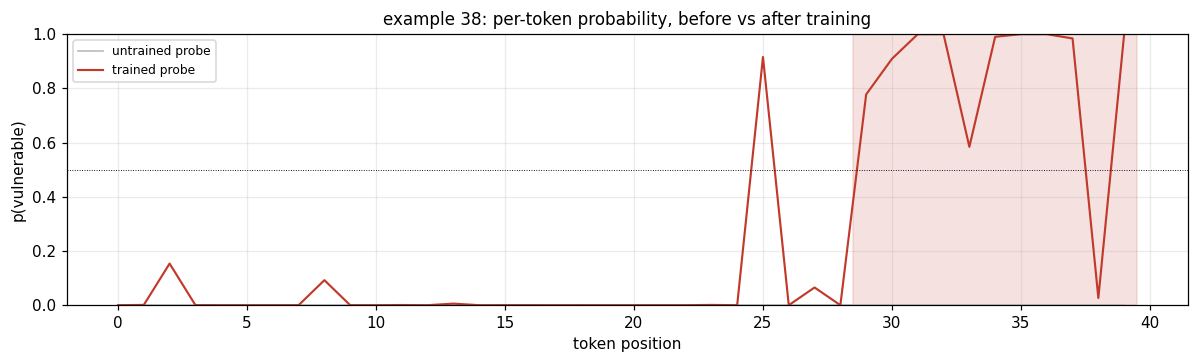

In [12]:
w_tr = torch.from_numpy(result["w"]).float()
b_tr = float(result["b"])
with torch.no_grad():
    logits_tr = (Xi @ w_tr + b_tr).numpy()
    probs_tr = torch.sigmoid(torch.from_numpy(logits_tr)).numpy()

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(probs0, color=NEU_C, lw=1.2, label="untrained probe")
ax.plot(probs_tr, color=POS_C, lw=1.4, label="trained probe")
ax.axhline(0.5, color="k", lw=0.6, ls=":")
for (s, e, lbl) in tok_spans:
    if lbl == 1:
        ax.axvspan(s - 0.5, min(e, n_tok - 1) + 0.5, color=POS_C, alpha=0.15)
ax.set_ylim(0, 1); ax.set_xlabel("token position"); ax.set_ylabel("p(vulnerable)")
ax.set_title(f"example {demo_eid}: per-token probability, before vs after training")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**The vulnerable example vs. its fixed twin.** The dataset is SVEN-paired:
the demo vulnerable example has a *correct* (non-vulnerable, label-0) sibling
from the **same function** — same `pair_group_key`. The probe should fire
inside the vulnerable span on the *before* code and stay quiet on the *fixed*
code. We find that sibling, run the trained probe over it, and plot both
after-training probability traces side by side.

correct sibling example_id=435  label=0  source=SVEN-before-leadup  file::func=cinder/volume/drivers/storwize_svc.py::_call_prepare_fc_map


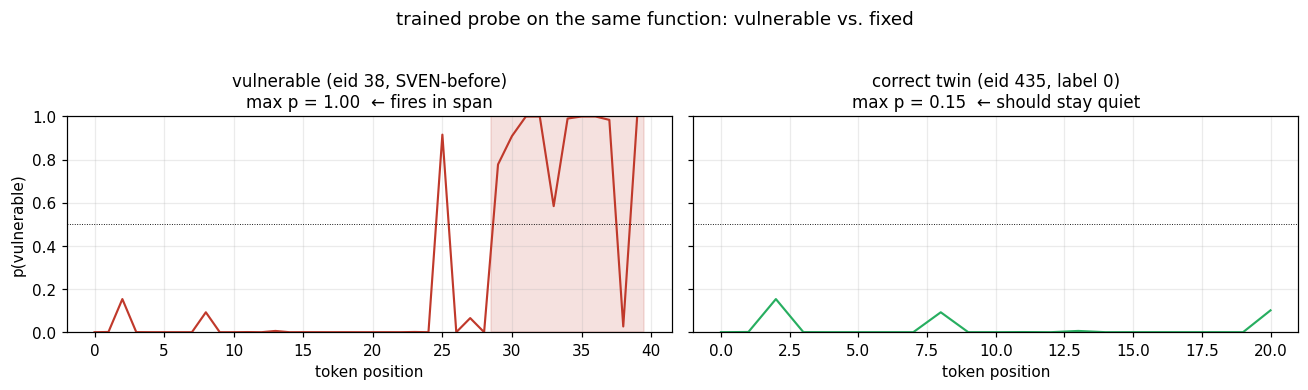

In [13]:
# locate the correct (label-0) sibling sharing the demo's group, present in sample
demo_group = eid_group[demo_eid]
correct_eid = next(
    (int(e) for e in sample_eids
     if eid_group[int(e)] == demo_group and _example_label(groups[int(e)][1]) == 0),
    None,
)
if correct_eid is None:  # fallback: any negative example in the sample
    correct_eid = next(int(e) for e in sample_eids if _example_label(groups[int(e)][1]) == 0)

crow = rows[correct_eid]
print(f"correct sibling example_id={correct_eid}  label={crow.get('label')}  "
      f"source={crow.get('source')}  file::func={crow.get('_file_name')}::{crow.get('_func_name')}")

Xc = torch.from_numpy(X_all[eid_all == correct_eid]).float()
with torch.no_grad():
    probs_correct = torch.sigmoid(Xc @ w_tr + b_tr).numpy()

fig, (axv, axc) = plt.subplots(1, 2, figsize=(12, 3.4), sharey=True)

# vulnerable (before) — trained probe, span shaded
axv.plot(probs_tr, color=POS_C, lw=1.4)
axv.axhline(0.5, color="k", lw=0.6, ls=":")
for (s, e, lbl) in tok_spans:
    if lbl == 1:
        axv.axvspan(s - 0.5, min(e, n_tok - 1) + 0.5, color=POS_C, alpha=0.15)
axv.set_title(f"vulnerable (eid {demo_eid}, SVEN-before)\n"
              f"max p = {probs_tr.max():.2f}  ← fires in span")
axv.set_xlabel("token position"); axv.set_ylabel("p(vulnerable)"); axv.set_ylim(0, 1)

# correct (fixed) twin — trained probe, no positive span to shade
axc.plot(probs_correct, color="#27ae60", lw=1.4)
axc.axhline(0.5, color="k", lw=0.6, ls=":")
axc.set_title(f"correct twin (eid {correct_eid}, label 0)\n"
              f"max p = {probs_correct.max():.2f}  ← should stay quiet")
axc.set_xlabel("token position")
fig.suptitle("trained probe on the same function: vulnerable vs. fixed", y=1.03)
plt.tight_layout()
plt.show()

## Stage 6 — Example-level scoring & ROC

At serve time the **example score** is the `max` token probability —
the single most-vulnerable-looking token speaks for the example
(`ex_p = p.max()`, the same max-pool the span term trains). We replay the
trained probe over the inner validation split and draw the two ROC curves
`train_one_layer` uses to choose the winning epoch/layer: token-level (every
token) and example-level (max-pooled).

validation token-AUC=0.777   example-AUC=0.625


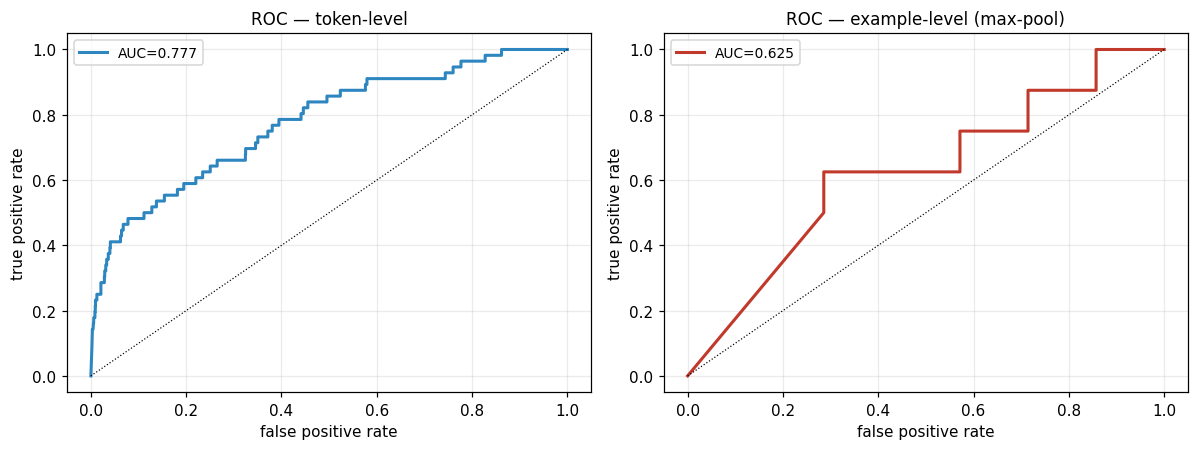

In [14]:
from sklearn.metrics import roc_auc_score, roc_curve

tok_y, tok_p, ex_y, ex_p = [], [], [], []
with torch.no_grad():
    for e in eids_val:
        Xe = torch.from_numpy(X_all[eid_all == e]).float()
        pe = torch.sigmoid(Xe @ w_tr + b_tr).numpy()
        ye = y_all[eid_all == e]
        tok_p.append(pe); tok_y.append(ye)
        ex_p.append(float(pe.max())); ex_y.append(int(ye.any()))
tok_y = np.concatenate(tok_y); tok_p = np.concatenate(tok_p)
ex_y = np.array(ex_y); ex_p = np.array(ex_p)

tok_auc_v = roc_auc_score(tok_y, tok_p) if len(np.unique(tok_y)) > 1 else float("nan")
ex_auc_v  = roc_auc_score(ex_y, ex_p) if len(np.unique(ex_y)) > 1 else float("nan")
print(f"validation token-AUC={tok_auc_v:.3f}   example-AUC={ex_auc_v:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (yv, pv, auc, name, c) in zip(
    axes,
    [(tok_y, tok_p, tok_auc_v, "token-level", "#2e86c1"),
     (ex_y, ex_p, ex_auc_v, "example-level (max-pool)", POS_C)],
):
    if len(np.unique(yv)) > 1:
        fpr, tpr, _ = roc_curve(yv, pv)
        ax.plot(fpr, tpr, color=c, lw=2, label=f"AUC={auc:.3f}")
    ax.plot([0, 1], [0, 1], "k:", lw=0.8)
    ax.set_title(f"ROC — {name}")
    ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Example-score separation.** The max-pooled probability per validation
example, split by true label — the gap is what the example-AUC measures.

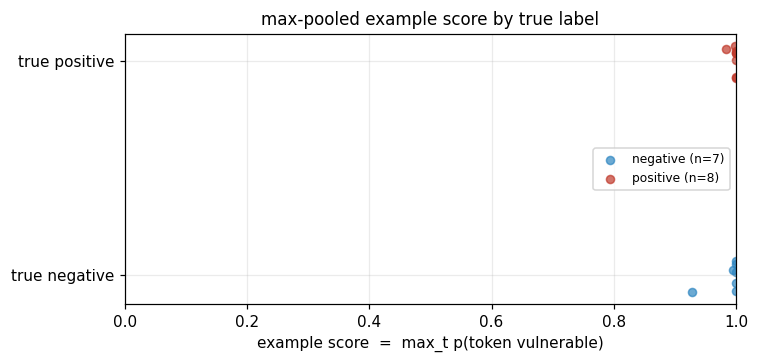

In [15]:
fig, ax = plt.subplots(figsize=(7, 3.4))
rng = np.random.default_rng(0)
for lab, c, name in [(0, NEG_C, "negative"), (1, POS_C, "positive")]:
    vals = ex_p[ex_y == lab]
    ax.scatter(vals, rng.uniform(-0.08, 0.08, size=len(vals)) + lab,
               color=c, alpha=0.7, s=28, label=f"{name} (n={len(vals)})")
ax.set_yticks([0, 1]); ax.set_yticklabels(["true negative", "true positive"])
ax.set_xlabel("example score  =  max_t p(token vulnerable)")
ax.set_xlim(0, 1)
ax.set_title("max-pooled example score by true label")
ax.legend(fontsize=8, loc="center right")
plt.tight_layout()
plt.show()

> **Read the numbers as scale, not score.** These AUCs come from a 150-example
> single-layer fp16 *sample* with ~15 validation examples — high variance by
> construction. They demonstrate that the pipeline runs and separates, not the
> probe's real quality. The production figure to compare against is in the
> probe card (e.g. layer-8 logreg AUC ≈ 0.846); reproduce it by pointing
> Stage 0 at the full `data/token_activations/`.

## Stage 7 — Bad examples (where the probe fails)

"Bad" here means the probe's **worst cases**: the weakest positives (vulnerable
code it *under*-scores → false-negative risk) and the strongest negatives
(safe code it *over*-scores → false-positive risk). We rank every sample
example by its `max`-pooled score, plot the per-token probability for the worst
of each kind, and **print the source code** so the failure is inspectable.

> Caveat: this layer-13 sample was trained on whole (Stage 5 passes all 150
> examples to `train_one_layer`, which holds out only its inner 10%), so most
> of these were *seen* during fit — read them as "what a failure looks like,"
> not as a generalization estimate. Point Stage 0 at the full
> `data/token_activations/` for an honest held-out failure audit.

In [16]:
THR = 0.5  # example-level decision threshold on max-pooled probability

def spans_for(eid: int):
    offs = [tuple(int(v) for v in o) for o in offsets_npz[f"offsets_row_{eid:04d}"]]
    return char_spans_to_token_spans(parse_spans(rows[eid]), offs), len(offs)

scored = []
with torch.no_grad():
    for e in sample_eids:
        e = int(e)
        p = torch.sigmoid(torch.from_numpy(X_all[eid_all == e]).float() @ w_tr + b_tr).numpy()
        scored.append({"eid": e, "label": int(y_all[eid_all == e].any()),
                       "maxp": float(p.max()), "p": p})

weak_pos = sorted([s for s in scored if s["label"] == 1], key=lambda s: s["maxp"])[:2]
strong_neg = sorted([s for s in scored if s["label"] == 0], key=lambda s: -s["maxp"])[:2]
bad = weak_pos + strong_neg

n_fn = sum(1 for s in scored if s["label"] == 1 and s["maxp"] < THR)
n_fp = sum(1 for s in scored if s["label"] == 0 and s["maxp"] >= THR)
print(f"at threshold {THR}: false negatives={n_fn}/{sum(s['label']==1 for s in scored)} positives  "
      f"false positives={n_fp}/{sum(s['label']==0 for s in scored)} negatives")

def _tag(s):
    if s["label"] == 1:
        return "FALSE NEGATIVE (missed vuln)" if s["maxp"] < THR else "weak positive"
    return "FALSE POSITIVE (false alarm)" if s["maxp"] >= THR else "strong negative"

# --- print the source text of each bad example ---
for s in bad:
    r = rows[s["eid"]]
    print("\n" + "=" * 88)
    print(f"eid={s['eid']}  label={s['label']}  max p={s['maxp']:.3f}  →  {_tag(s)}")
    print(f"source={r.get('source')}  cwe={r.get('cwe')}  lang={r.get('lang')}  "
          f"file::func={r.get('_file_name')}::{r.get('_func_name')}")
    print("-" * 88)
    lines = r["code"].splitlines()
    MAXL = 45
    print("\n".join(lines[:MAXL]))
    if len(lines) > MAXL:
        print(f"... [{len(lines) - MAXL} more lines truncated]")

at threshold 0.5: false negatives=0/75 positives  false positives=71/75 negatives

eid=703  label=1  max p=0.947  →  weak positive
source=SVEN-before  cwe=CWE-476  lang=c  file::func=src/xkbcomp/keymap.c::CompileKeymap
----------------------------------------------------------------------------------------
CompileKeymap(XkbFile *file, struct xkb_keymap *keymap, enum merge_mode merge)
{
    bool ok;
    XkbFile *files[LAST_KEYMAP_FILE_TYPE + 1] = { NULL };
    enum xkb_file_type type;
    struct xkb_context *ctx = keymap->ctx;

    /* Collect section files and check for duplicates. */
    for (file = (XkbFile *) file->defs; file;
         file = (XkbFile *) file->common.next) {
        if (file->file_type < FIRST_KEYMAP_FILE_TYPE ||
            file->file_type > LAST_KEYMAP_FILE_TYPE) {
            log_err(ctx, "Cannot define %s in a keymap file\n",
                    xkb_file_type_to_string(file->file_type));
            continue;
        }

        if (files[file->file_type]) {
    


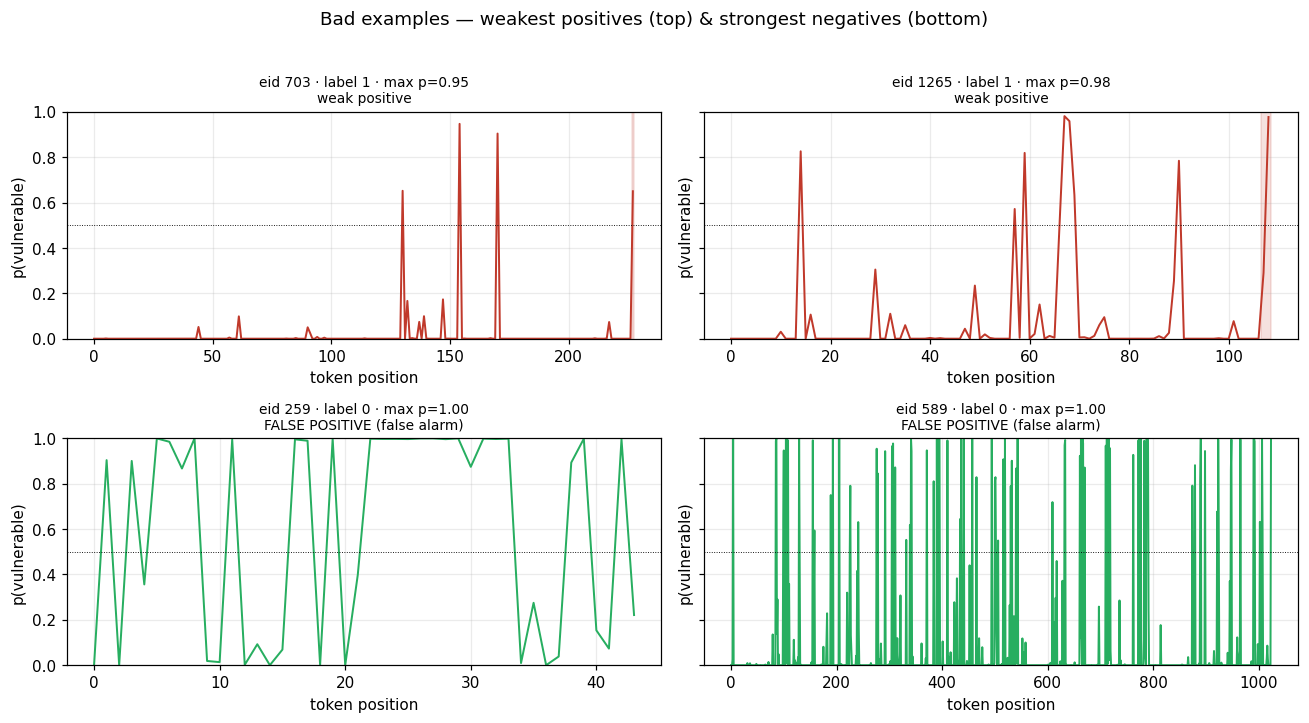

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6.4), sharey=True)
for ax, s in zip(axes.ravel(), bad):
    tspans, ntok = spans_for(s["eid"])
    c = POS_C if s["label"] == 1 else "#27ae60"
    ax.plot(s["p"], color=c, lw=1.3)
    ax.axhline(THR, color="k", lw=0.6, ls=":")
    for (a, b_, lbl) in tspans:
        if lbl == 1:
            ax.axvspan(a - 0.5, min(b_, ntok - 1) + 0.5, color=POS_C, alpha=0.15)
    ax.set_ylim(0, 1)
    ax.set_title(f"eid {s['eid']} · label {s['label']} · max p={s['maxp']:.2f}\n{_tag(s)}",
                 fontsize=9)
    ax.set_xlabel("token position"); ax.set_ylabel("p(vulnerable)")
fig.suptitle("Bad examples — weakest positives (top) & strongest negatives (bottom)", y=1.02)
plt.tight_layout()
plt.show()

## Stage 8 — Calibrated operating point (reproducing the F1-max threshold)

Stage 7's `0.5` cut on raw `sigmoid` scores over-fired (71/75 FP). The
production system (gemmaforge) doesn't use 0.5 — it **Platt-calibrates** the
probe, then picks the **F1-maximizing** threshold on calibrated scores:
`threshold = 0.929`, with `T ≈ 1.794`, `a ≈ −0.269`, giving precision 0.49 /
recall 0.35 on its heldout repo benchmark.

Those exact numbers belong to the production layer-8 probe — not transferable
to our layer-13 sample probe. So we reproduce the **procedure**, not the
constants:
1. example score = `max_t (w·h_t + b)` (a raw logit; `sigmoid` of it is the
   max-pool probability from Stage 6).
2. fit Platt `sigmoid((logit − a)/T)` on those scores (the repo's own
   `apply_platt`), via a near-unregularized logistic fit.
3. sweep thresholds `linspace(0.01, 0.99, 99)`, take F1-max — exactly
   gemmaforge's `eval_calibration.py`.

> Two caveats. (1) Same trained-on-sample issue as Stage 7 — fit and eval on
> the same 150 examples, so this is illustrative of the *method*, not a
> deployable operating point. (2) The threshold value is **not comparable**
> across probes: Platt remaps each probe onto its own calibrated axis, so this
> sample's F1-max threshold and gemmaforge's 0.929 sit on different scales.
> What transfers is the procedure (calibrate → F1-max), not the number.

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
from src.probes.calibration import apply_platt

# (1) example-level raw logit = max over tokens of (w·h + b)
sample_eid_list = [int(e) for e in sample_eids]
ex_logit = np.array([
    float((torch.from_numpy(X_all[eid_all == e]).float() @ w_tr + b_tr).max())
    for e in sample_eid_list
])
ex_lab = np.array([int(y_all[eid_all == e].any()) for e in sample_eid_list])

# (2) Platt fit: sigmoid(A·logit + B) == sigmoid((logit − a)/T)  ->  T=1/A, a=−B/A
platt = LogisticRegression(C=1e6, solver="lbfgs", max_iter=1000)
platt.fit(ex_logit.reshape(-1, 1), ex_lab)
A = float(platt.coef_[0, 0]); B = float(platt.intercept_[0])
T_fit, a_fit = 1.0 / A, -B / A
ex_cal = apply_platt(ex_logit, T_fit, a_fit)   # calibrated example probabilities
print(f"Platt fit on layer-13 sample probe:  T={T_fit:.3f}  a={a_fit:.3f}")
print(f"(gemmaforge production: T≈1.794  a≈-0.269  threshold 0.929 — layer-8 probe, heldout benchmark)")

# (3) F1-max sweep on calibrated scores (same grid as eval_calibration.py)
ths = np.linspace(0.01, 0.99, 99)
prec = np.array([precision_score(ex_lab, ex_cal >= t, zero_division=0) for t in ths])
rec  = np.array([recall_score(ex_lab, ex_cal >= t, zero_division=0) for t in ths])
f1s  = np.array([f1_score(ex_lab, ex_cal >= t, zero_division=0) for t in ths])
bi = int(np.argmax(f1s)); thr = float(ths[bi])
print(f"\nF1-max threshold (this sample) = {thr:.3f}  "
      f"precision={prec[bi]:.3f}  recall={rec[bi]:.3f}  F1={f1s[bi]:.3f}")

def _conf(scores, t):
    pred = (np.asarray(scores) >= t).astype(int)
    tp = int(((pred == 1) & (ex_lab == 1)).sum()); fp = int(((pred == 1) & (ex_lab == 0)).sum())
    fn = int(((pred == 0) & (ex_lab == 1)).sum()); tn = int(((pred == 0) & (ex_lab == 0)).sum())
    return f"TP={tp} FP={fp} FN={fn} TN={tn}"

raw_maxp = 1.0 / (1.0 + np.exp(-ex_logit))     # uncalibrated max-pool prob
print(f"\nraw  @ 0.500 :  {_conf(raw_maxp, 0.5)}   <- Stage 7's over-firing")
print(f"cal  @ {thr:.3f}:  {_conf(ex_cal, thr)}   <- calibrated F1-max")

Platt fit on layer-13 sample probe:  T=7.031  a=12.791
(gemmaforge production: T≈1.794  a≈-0.269  threshold 0.929 — layer-8 probe, heldout benchmark)



F1-max threshold (this sample) = 0.290  precision=0.574  recall=0.933  F1=0.711

raw  @ 0.500 :  TP=75 FP=71 FN=0 TN=4   <- Stage 7's over-firing
cal  @ 0.290:  TP=70 FP=52 FN=5 TN=23   <- calibrated F1-max


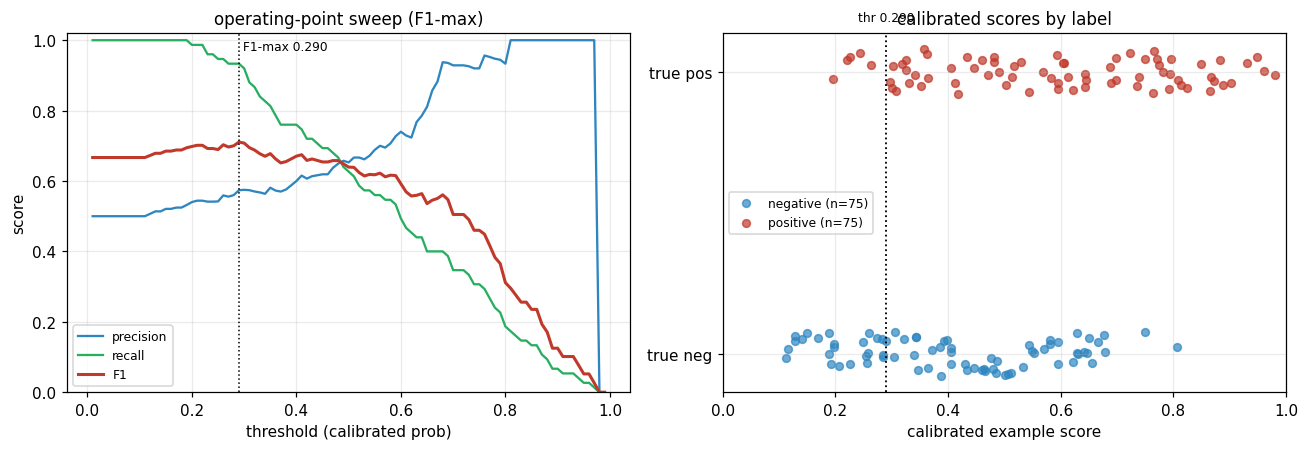

In [19]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 4.2))
axA.plot(ths, prec, label="precision", color="#2e86c1")
axA.plot(ths, rec, label="recall", color="#27ae60")
axA.plot(ths, f1s, label="F1", color=POS_C, lw=2)
axA.axvline(thr, color="k", ls=":", lw=1)
axA.text(thr, 1.0, f" F1-max {thr:.3f}", fontsize=8, va="top")
axA.set_xlabel("threshold (calibrated prob)"); axA.set_ylabel("score")
axA.set_title("operating-point sweep (F1-max)"); axA.set_ylim(0, 1.02); axA.legend(fontsize=8)

rng = np.random.default_rng(1)
for lab, c, name in [(0, NEG_C, "negative"), (1, POS_C, "positive")]:
    v = ex_cal[ex_lab == lab]
    axB.scatter(v, rng.uniform(-0.08, 0.08, len(v)) + lab, color=c, alpha=0.7, s=26,
                label=f"{name} (n={len(v)})")
axB.axvline(thr, color="k", ls=":", lw=1.2)
axB.text(thr, 1.18, f"thr {thr:.3f}", fontsize=8, ha="center")
axB.set_yticks([0, 1]); axB.set_yticklabels(["true neg", "true pos"])
axB.set_xlabel("calibrated example score"); axB.set_xlim(0, 1)
axB.set_title("calibrated scores by label")
axB.legend(fontsize=8, loc="center left")
plt.tight_layout()
plt.show()

**Stage-7 bad examples, re-judged at the calibrated threshold** — and the text
of whatever still misfires here.

In [20]:
cal_by = dict(zip(sample_eid_list, ex_cal))
lab_by = dict(zip(sample_eid_list, ex_lab))

print("Stage-7 'bad' examples at the calibrated F1-max threshold:")
for s in bad:
    e = s["eid"]; cs = cal_by[e]; dec = "risky" if cs >= thr else "safe"
    ok = "✓" if (dec == "risky") == (s["label"] == 1) else "✗"
    print(f"  eid {e}: label {s['label']}  raw maxp={s['maxp']:.2f}  cal={cs:.2f}  -> {dec} {ok}")

fps = sorted([(e, c) for e, c in cal_by.items() if lab_by[e] == 0 and c >= thr], key=lambda x: -x[1])
fns = sorted([(e, c) for e, c in cal_by.items() if lab_by[e] == 1 and c < thr], key=lambda x: x[1])
print(f"\nat threshold {thr:.3f}:  remaining false alarms={len(fps)}  missed vulns={len(fns)}")

for name, lst in [("worst FALSE ALARM (safe code, scored risky)", fps[:1]),
                  ("worst MISS (vuln code, scored safe)", fns[:1])]:
    for e, c in lst:
        r = rows[e]
        print("\n" + "=" * 88)
        print(f"{name}: eid={e}  label={lab_by[e]}  cal_score={c:.3f}")
        print(f"source={r.get('source')}  cwe={r.get('cwe')}  lang={r.get('lang')}  "
              f"file::func={r.get('_file_name')}::{r.get('_func_name')}")
        print("-" * 88)
        ls = r["code"].splitlines()
        print("\n".join(ls[:35]))
        if len(ls) > 35:
            print(f"... [{len(ls) - 35} more lines truncated]")

Stage-7 'bad' examples at the calibrated F1-max threshold:
  eid 703: label 1  raw maxp=0.95  cal=0.20  -> safe ✗
  eid 1265: label 1  raw maxp=0.98  cal=0.22  -> safe ✗
  eid 259: label 0  raw maxp=1.00  cal=0.64  -> risky ✗
  eid 589: label 0  raw maxp=1.00  cal=0.75  -> risky ✗

at threshold 0.290:  remaining false alarms=52  missed vulns=5

worst FALSE ALARM (safe code, scored risky): eid=1434  label=0  cal_score=0.806
source=SVEN-before-leadup  cwe=None  lang=python  file::func=desktop/libs/dashboard/src/dashboard/views.py::index
----------------------------------------------------------------------------------------
def index(request, is_mobile=False):
  hue_collections = DashboardController(request.user).get_search_collections()
  collection_id = request.GET.get('collection')

  if not hue_collections or not collection_id:
    return admin_collections(request, True, is_mobile)

  try:
    collection_doc = Document2.objects.get(id=collection_id)
    if USE_NEW_EDITOR.get():
     

---
### Recap — the full chain, all faithful to source

| Stage | Source | What you saw |
|---|---|---|
| 1 | `token_data.py` | code → tokens → char-spans → token-spans → per-token labels (verified == on-disk `y`) |
| 2 | `retrain_spanmax_sven_split.py` + `train_probe_spanmax.py` | outer group-clean heldout, inner stratified 90/10 |
| 3 | `LinearProbe` | per-token logit `w·h+b` → `sigmoid` probability |
| 4 | `span_max_loss` | weighted-BCE token term + max-pool span term + omega anneal (asserted equal to source) |
| 5 | `train_one_layer` | real loop: loss / token-AUC / example-AUC / omega; before-vs-after |
| 6 | `train_one_layer` eval | max-pool example score, token & example ROC |
| 7 | this notebook | bad examples: weakest positives / strongest negatives + source text |
| 8 | `probes/calibration.py` + F1-sweep | Platt-calibrate, reproduce the F1-max operating point (gemmaforge's 0.929 procedure) |

To trace a **different layer** or the full dataset, point Stage 0 at the
production `data/token_activations/token_activations_layer{NN}.npz` and rerun.
Nothing else changes — the logic is layer-agnostic.